# Variabilité des réponses LLM

Objectif : envoyer **100 prompts identiques** au même modèle **10 fois** chacun,  
puis mesurer la stabilité des réponses prompt par prompt.

Métriques calculées :
- **Taux de cohérence** : % de runs qui choisissent le mode majoritaire
- **Entropie de Shannon** : variabilité de la distribution des modes par prompt
- **Modes distincts** : nombre de modes différents observés sur les N runs

L'exercice peut être relancé sur un autre modèle en changeant `PROVIDER_NAME` / `MODEL_NAME`.

> ⚠️ **Depuis le passage au choix modal probabiliste** (2026-07-29), le modèle ne
> choisit plus une option : il attribue une probabilité à **chacune** (somme = 100).
>
> `chosen_index` est ici reconstruit comme l'**argmax** de cette distribution
> (`probability_compat.decision_index`) : les analyses ci-dessous continuent donc de
> mesurer exactement ce qu'elles mesuraient. Mais ce n'est plus ce que fait la
> simulation, qui **tire au sort** dans la distribution.
>
> **Reformulation à envisager** : l'hésitation du modèle, jusqu'ici estimée en
> répétant les appels et en mesurant la dispersion des choix, est désormais lisible
> **directement** dans un seul appel — colonne `entropy` (0 = certitude, 1 = indécision
> totale). Bien moins bruité, et gratuit en requêtes.


In [17]:
import os, certifi
os.environ['SSL_CERT_FILE'] = certifi.where()
os.environ['REQUESTS_CA_BUNDLE'] = certifi.where()

In [18]:
import sys, json, time, random, re
from pathlib import Path

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from tqdm.notebook import tqdm
from dotenv import load_dotenv

load_dotenv(Path('../../.env'))
sys.path.insert(0, str(Path('../..').resolve()))

from llm_module.adapters.base import get_adapter, ProviderClientError, ProviderServerError, ProviderParseError
from llm_module.settings.models import InternalMessage, InternalRequest
from llm_module.tasks.llm_config import settings

# ── Config principale ────────────────────────────────────────────────────────
PROVIDER_NAME = 'mistral'        # ← changer ici pour comparer des modèles
MODEL_NAME    = None             # None = modèle par défaut du provider
TEMPERATURE   = 0.15
N_RUNS        = 10               # répétitions par prompt
SAMPLE_SIZE   = 100              # nombre de prompts distincts
PROMPT_KEY    = 'persona_v1'     # clé dans prompts.yaml
CATEGORY      = 'itinary_multi_agent'
RANDOM_SEED   = 42

# ── Chemins ──────────────────────────────────────────────────────────────────
PROJECT_ROOT   = Path('../..')
EXCHANGES_FILE = PROJECT_ROOT / 'experiments' / 'current' / 'llm_exchanges.jsonl'
SCHEMAS_FILE   = PROJECT_ROOT / 'llm_module' / 'prompts' / 'schemas.json'
PROMPTS_FILE   = Path('prompts.yaml')
CEREMA_FILE    = PROJECT_ROOT / 'scripts' / 'data' / 'population' / 'cerema_values.yaml'
RESULTS_DIR    = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

model_slug  = (MODEL_NAME or settings.providers[PROVIDER_NAME].default_model).replace('/', '-')
OUTPUT_CSV  = RESULTS_DIR / f'variability_{PROVIDER_NAME}_{model_slug}_T{TEMPERATURE}.csv'

provider_cfg = settings.providers[PROVIDER_NAME]
RPM_LIMIT    = provider_cfg.rpm_limit

print(f'Provider  : {PROVIDER_NAME}')
print(f'Modèle    : {model_slug}')
print(f'Temp.     : {TEMPERATURE}')
print(f'Runs/prompt: {N_RUNS}  ×  {SAMPLE_SIZE} prompts  =  {N_RUNS * SAMPLE_SIZE} appels LLM')
print(f'RPM limit : {RPM_LIMIT}  →  durée estimée : ~{N_RUNS * SAMPLE_SIZE / RPM_LIMIT:.1f} min')
print(f'Output    : {OUTPUT_CSV}')

Provider  : mistral
Modèle    : mistral-small-latest
Temp.     : 0.15
Runs/prompt: 10  ×  100 prompts  =  1000 appels LLM
RPM limit : 90  →  durée estimée : ~11.1 min
Output    : results/variability_mistral_mistral-small-latest_T0.15.csv


## 1 — Chargement des prompts et du schéma

In [19]:
def parse_multiline_jsonl(path: Path) -> list:
    content = path.read_text(encoding='utf-8').strip()
    decoder = json.JSONDecoder()
    entries, pos = [], 0
    while pos < len(content):
        stripped = content[pos:].lstrip()
        pos += len(content[pos:]) - len(stripped)
        if not stripped:
            break
        obj, offset = decoder.raw_decode(stripped)
        entries.append(obj)
        pos += offset
    return entries


all_entries = parse_multiline_jsonl(EXCHANGES_FILE)
eligible    = [e for e in all_entries if e.get('category') == CATEGORY]

random.seed(RANDOM_SEED)
eval_entries = random.sample(eligible, min(SAMPLE_SIZE, len(eligible)))

with open(SCHEMAS_FILE) as f:
    RESPONSE_SCHEMA = json.load(f)[CATEGORY]

with open(PROMPTS_FILE) as f:
    prompts_db = yaml.safe_load(f)
SYSTEM_PROMPT = prompts_db['prompts'][PROMPT_KEY]['content']

print(f'Entrées totales    : {len(all_entries)}')
print(f'Éligibles          : {len(eligible)}')
print(f'Prompts sélection. : {len(eval_entries)}')
print(f'Prompt système     : {PROMPT_KEY!r} ({len(SYSTEM_PROMPT)} chars)')

with open(CEREMA_FILE) as f:
    cerema = yaml.safe_load(f)
CEREMA_GLOBAL = {
    'Marche':  cerema['parts_modales_2023']['global']['marche'],
    'Voiture': cerema['parts_modales_2023']['global']['voiture'],
    'Vélo':    cerema['parts_modales_2023']['global']['velo'],
    'TC':      cerema['parts_modales_2023']['global']['transports_collectifs'],
}
print(f'Référence EMC² 2023 : {CEREMA_GLOBAL}')

Entrées totales    : 167
Éligibles          : 150
Prompts sélection. : 100
Prompt système     : 'persona_v1' (1896 chars)
Référence EMC² 2023 : {'Marche': 26, 'Voiture': 55, 'Vélo': 4, 'TC': 12}


## 2 — Fonction d'appel

In [20]:
from probability_compat import decision_index, entropy_of, probabilities_of

MAX_RETRIES    = 5
MAX_RETRY_WAIT = 300.0


def _parse_ratelimit_reset(value, default: int = 60) -> int:
    if not value:
        return default
    m = re.match(r'^(\d+)s?$', str(value).strip())
    if m:
        return int(m.group(1)) + 2
    m = re.match(r'^(\d+)m(\d+)s?$', str(value).strip())
    if m:
        return int(m.group(1)) * 60 + int(m.group(2)) + 2
    try:
        return int(value) + 2
    except (ValueError, TypeError):
        return default


def call_once(entry: dict) -> list:
    raw = entry['messages']
    messages = [
        InternalMessage(role=raw[0]['role'], content=SYSTEM_PROMPT),
        *[InternalMessage(role=m['role'], content=m['content']) for m in raw[1:]],
    ]
    kwargs = dict(provider=PROVIDER_NAME, messages=messages,
                  response_schema=RESPONSE_SCHEMA, temperature=TEMPERATURE)
    if MODEL_NAME:
        kwargs['model'] = MODEL_NAME
    req = InternalRequest(**kwargs)
    out, _, _ = get_adapter(PROVIDER_NAME).call(req)
    # `chosen_index` n'existe plus : le modèle renvoie une distribution. On garde
    # l'option qu'il privilégie (argmax) pour préserver la mesure historique, et on
    # conserve la distribution complète — l'hésitation y est directement lisible.
    return [{'agent_id': a.agent_id, 'chosen_index': decision_index(a),
             'probabilities': probabilities_of(a), 'entropy': entropy_of(a),
             'mode': a.mode, 'reason': a.reason}
            for a in out.agents]


def call_with_retry(entry: dict) -> list:
    parse_tries = 0
    for attempt in range(MAX_RETRIES + 1):
        try:
            return call_once(entry)
        except ProviderClientError as exc:
            if exc.status_code == 429 and attempt < MAX_RETRIES:
                wait = _parse_ratelimit_reset(getattr(exc, 'ratelimit_reset', None))
                if wait > MAX_RETRY_WAIT:
                    raise
                time.sleep(wait)
            else:
                raise
        except ProviderServerError:
            if attempt < MAX_RETRIES:
                time.sleep(2 ** attempt)
            else:
                raise
        except ProviderParseError:
            if parse_tries < 1:
                parse_tries += 1
                time.sleep(2.0)
            else:
                raise

## 3 — Exécution : N_RUNS × 100 prompts

Le CSV de sortie contient une ligne par agent par run.  
La colonne `run_id` (0 à N_RUNS-1) permet de suivre quelle répétition a produit quelle réponse.  
La reprise automatique saute les (prompt_idx, run_id) déjà présents dans le CSV.

In [21]:
# ── Reprise ───────────────────────────────────────────────────────────────────
if OUTPUT_CSV.exists() and OUTPUT_CSV.stat().st_size > 100:
    existing_df = pd.read_csv(OUTPUT_CSV, engine='python')
    done_keys   = set(zip(existing_df['prompt_idx'], existing_df['run_id']))
    print(f'Reprise : {len(done_keys)} (prompt_idx, run_id) déjà traités')
else:
    done_keys = set()
    if OUTPUT_CSV.exists():
        OUTPUT_CSV.unlink()
    print('Nouveau run')

# ── Boucle principale ─────────────────────────────────────────────────────────
min_interval       = 60.0 / RPM_LIMIT
last_call_ts       = 0.0
total_new_rows     = 0
consecutive_errors = 0
MAX_CONSECUTIVE    = 10

total_calls = len(eval_entries) * N_RUNS
pbar        = tqdm(total=total_calls, desc='Variabilité')

for run_id in range(N_RUNS):
    for prompt_idx, entry in enumerate(eval_entries):
        pbar.update(1)
        if (prompt_idx, run_id) in done_keys:
            continue

        now  = time.monotonic()
        wait = min_interval - (now - last_call_ts)
        if wait > 0:
            time.sleep(wait)
        last_call_ts = time.monotonic()

        try:
            agents = call_with_retry(entry)
            consecutive_errors = 0
            rows = [
                {
                    'run_id':       run_id,
                    'prompt_idx':   prompt_idx,
                    'agent_id':     a['agent_id'],
                    'chosen_index': a['chosen_index'],
                    'probabilities': a.get('probabilities'),
                    'entropy':      a.get('entropy'),
                    'mode':         a['mode'],
                    'reason':       a['reason'],
                }
                for a in agents
            ]
            total_new_rows += len(rows)
            write_header = not OUTPUT_CSV.exists()
            pd.DataFrame(rows).to_csv(OUTPUT_CSV, mode='a', header=write_header, index=False)
        except Exception as exc:
            consecutive_errors += 1
            tqdm.write(f'ECHEC run={run_id} prompt={prompt_idx} ({consecutive_errors}/{MAX_CONSECUTIVE}): {exc}')
            if consecutive_errors >= MAX_CONSECUTIVE:
                tqdm.write('Abandon après trop d\'erreurs consécutives')
                pbar.close()
                break
    else:
        continue
    break

pbar.close()
print(f'Terminé — {total_new_rows} nouvelles lignes collectées → {OUTPUT_CSV}')

Nouveau run


Variabilité:   0%|          | 0/1000 [00:00<?, ?it/s]

Terminé — 2710 nouvelles lignes collectées → results/variability_mistral_mistral-small-latest_T0.15.csv


## 4 — Chargement et nettoyage

In [22]:
MODE_COLORS = {
    'Voiture': '#EE4444',
    'Vélo':    '#8844BB',
    'TC':      '#22AA44',
    'Marche':  '#00CCCC',
    'Autre':   '#999999',
}
MODE_ORDER = ['Marche', 'Voiture', 'Vélo', 'TC', 'Autre']


def categorize_mode(m: str) -> str:
    if not isinstance(m, str):
        return 'Autre'
    ml = m.lower()
    if any(k in ml for k in ('bus', 'metro', 'métro', 'tram', 'transit', 'transports en commun', 'public_transport')):
        return 'TC'
    if any(k in ml for k in ('voiture', 'car', 'conducteur')):
        return 'Voiture'
    if any(k in ml for k in ('vélo', 'velo', 'bicycle', 'cycling')):
        return 'Vélo'
    if any(k in ml for k in ('marche', 'foot', 'walk')):
        return 'Marche'
    return 'Autre'


df_raw   = pd.read_csv(OUTPUT_CSV, engine='python')
df_valid = df_raw[df_raw['chosen_index'].between(1, 5)].copy()
df_valid['mode_cat'] = df_valid['mode'].apply(categorize_mode)

n_prompts = df_valid['prompt_idx'].nunique()
n_runs    = df_valid['run_id'].nunique()

print(f'Lignes totales  : {len(df_raw)}')
print(f'Lignes valides  : {len(df_valid)}')
print(f'Prompts couverts: {n_prompts} / {SAMPLE_SIZE}')
print(f'Runs couverts   : {n_runs} / {N_RUNS}')
df_valid.head()

Lignes totales  : 2710
Lignes valides  : 2128
Prompts couverts: 89 / 100
Runs couverts   : 10 / 10


,run_id,prompt_idx,agent_id,chosen_index,mode,reason,mode_cat
0,0,0,839099,3,car,Temps de trajet optimal (33 min) malgré la dis...,Voiture
1,0,0,699521,4,bicycle,Trajet ultra-rapide (5 min) et sans effort cog...,Vélo
2,0,0,1396214,3,car,Trajet direct et rapide (25 min) malgré un coû...,Voiture
3,0,0,1047277,3,car,Trajet le plus rapide (15 min) et direct pour ...,Voiture
5,0,0,1160469,1,"foot,bus,foot",Trajet rapide (21 min) avec une marche modérée...,TC


## 5 — Métriques de variabilité par prompt

In [23]:
def shannon_entropy(series: pd.Series) -> float:
    counts = series.value_counts(normalize=True)
    return float(-(counts * np.log2(counts + 1e-12)).sum())


def majority_pct(series: pd.Series) -> float:
    return float(series.value_counts(normalize=True).iloc[0] * 100)


# Une ligne par (prompt_idx, agent_id) × toutes les répétitions
# On agrège sur le niveau prompt (toutes les réponses du prompt sur tous les runs)
per_prompt = (
    df_valid
    .groupby('prompt_idx')['mode_cat']
    .agg(
        n_responses='count',
        n_distinct_modes=lambda s: s.nunique(),
        entropy=shannon_entropy,
        majority_pct=majority_pct,
        majority_mode=lambda s: s.value_counts().index[0],
    )
    .reset_index()
)

# Entropie max possible (équidistribution sur les 4 modes principaux)
MAX_ENTROPY = np.log2(4)
per_prompt['entropy_norm'] = per_prompt['entropy'] / MAX_ENTROPY

print('Statistiques globales de variabilité :')
print(f"  Cohérence moyenne (% mode majoritaire) : {per_prompt['majority_pct'].mean():.1f}%")
print(f"  Entropie moyenne                       : {per_prompt['entropy'].mean():.3f} bits")
print(f"  Entropie normalisée moyenne             : {per_prompt['entropy_norm'].mean():.3f} (0=stable, 1=aléatoire)")
print(f"  Modes distincts moyens/prompt           : {per_prompt['n_distinct_modes'].mean():.2f}")
print()
per_prompt.sort_values('entropy', ascending=False).head(10)

Statistiques globales de variabilité :
  Cohérence moyenne (% mode majoritaire) : 73.5%
  Entropie moyenne                       : 0.700 bits
  Entropie normalisée moyenne             : 0.350 (0=stable, 1=aléatoire)
  Modes distincts moyens/prompt           : 1.96



,prompt_idx,n_responses,n_distinct_modes,entropy,majority_pct,majority_mode,entropy_norm
2,2,40,4,2.000000,25.000000,Voiture,1.000000
26,30,70,4,1.930323,37.142857,Voiture,0.965162
32,36,86,4,1.868475,37.209302,TC,0.934237
33,37,190,4,1.853548,40.526316,TC,0.926774
27,31,29,4,1.807283,44.827586,Vélo,0.903641
18,22,30,4,1.806905,43.333333,Voiture,0.903452
0,0,125,4,1.630657,55.200000,Voiture,0.815328
50,55,30,3,1.584963,33.333333,Vélo,0.792481
70,79,57,3,1.575395,36.842105,Vélo,0.787697
3,3,10,3,1.570951,40.000000,Marche,0.785475


## 6 — Visualisations

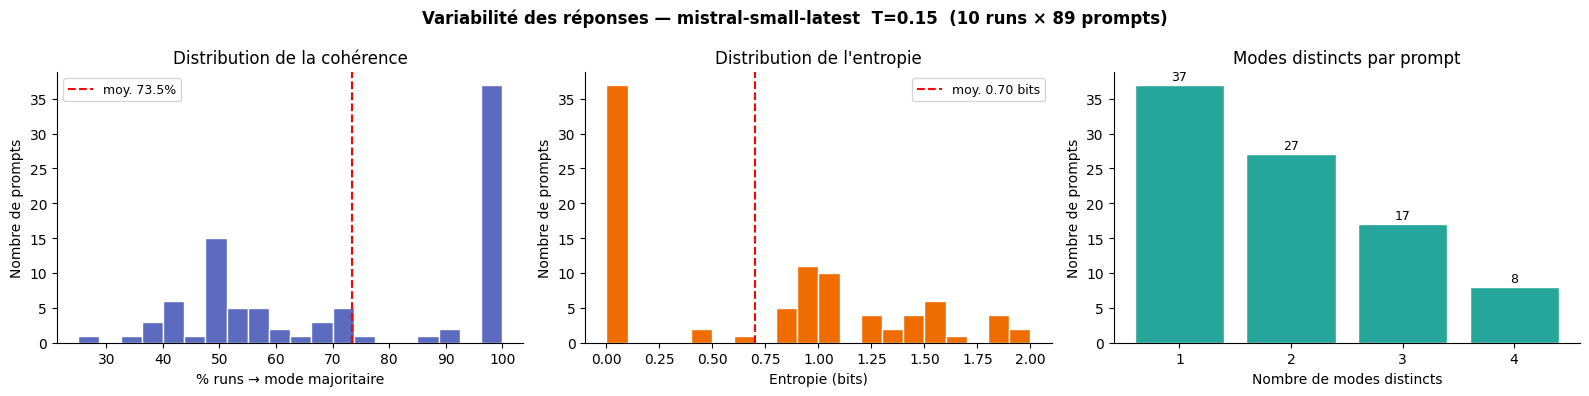

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(
    f'Variabilité des réponses — {model_slug}  T={TEMPERATURE}  ({N_RUNS} runs × {n_prompts} prompts)',
    fontsize=12, fontweight='bold'
)

# ── Histogramme cohérence ────────────────────────────────────────────────────
ax = axes[0]
ax.hist(per_prompt['majority_pct'], bins=20, color='#5C6BC0', edgecolor='white')
ax.axvline(per_prompt['majority_pct'].mean(), color='red', linestyle='--',
           label=f"moy. {per_prompt['majority_pct'].mean():.1f}%")
ax.set_xlabel('% runs → mode majoritaire')
ax.set_ylabel('Nombre de prompts')
ax.set_title('Distribution de la cohérence')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# ── Histogramme entropie ─────────────────────────────────────────────────────
ax = axes[1]
ax.hist(per_prompt['entropy'], bins=20, color='#EF6C00', edgecolor='white')
ax.axvline(per_prompt['entropy'].mean(), color='red', linestyle='--',
           label=f"moy. {per_prompt['entropy'].mean():.2f} bits")
ax.set_xlabel('Entropie (bits)')
ax.set_ylabel('Nombre de prompts')
ax.set_title('Distribution de l\'entropie')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# ── Barplot modes distincts ───────────────────────────────────────────────────
ax = axes[2]
vc = per_prompt['n_distinct_modes'].value_counts().sort_index()
ax.bar(vc.index.astype(str), vc.values, color='#26A69A', edgecolor='white')
ax.set_xlabel('Nombre de modes distincts')
ax.set_ylabel('Nombre de prompts')
ax.set_title('Modes distincts par prompt')
ax.spines[['top', 'right']].set_visible(False)
for x, v in zip(vc.index, vc.values):
    ax.text(str(x), v + 0.3, str(v), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / f'variability_overview_{model_slug}_T{TEMPERATURE}.png', dpi=150)
plt.show()

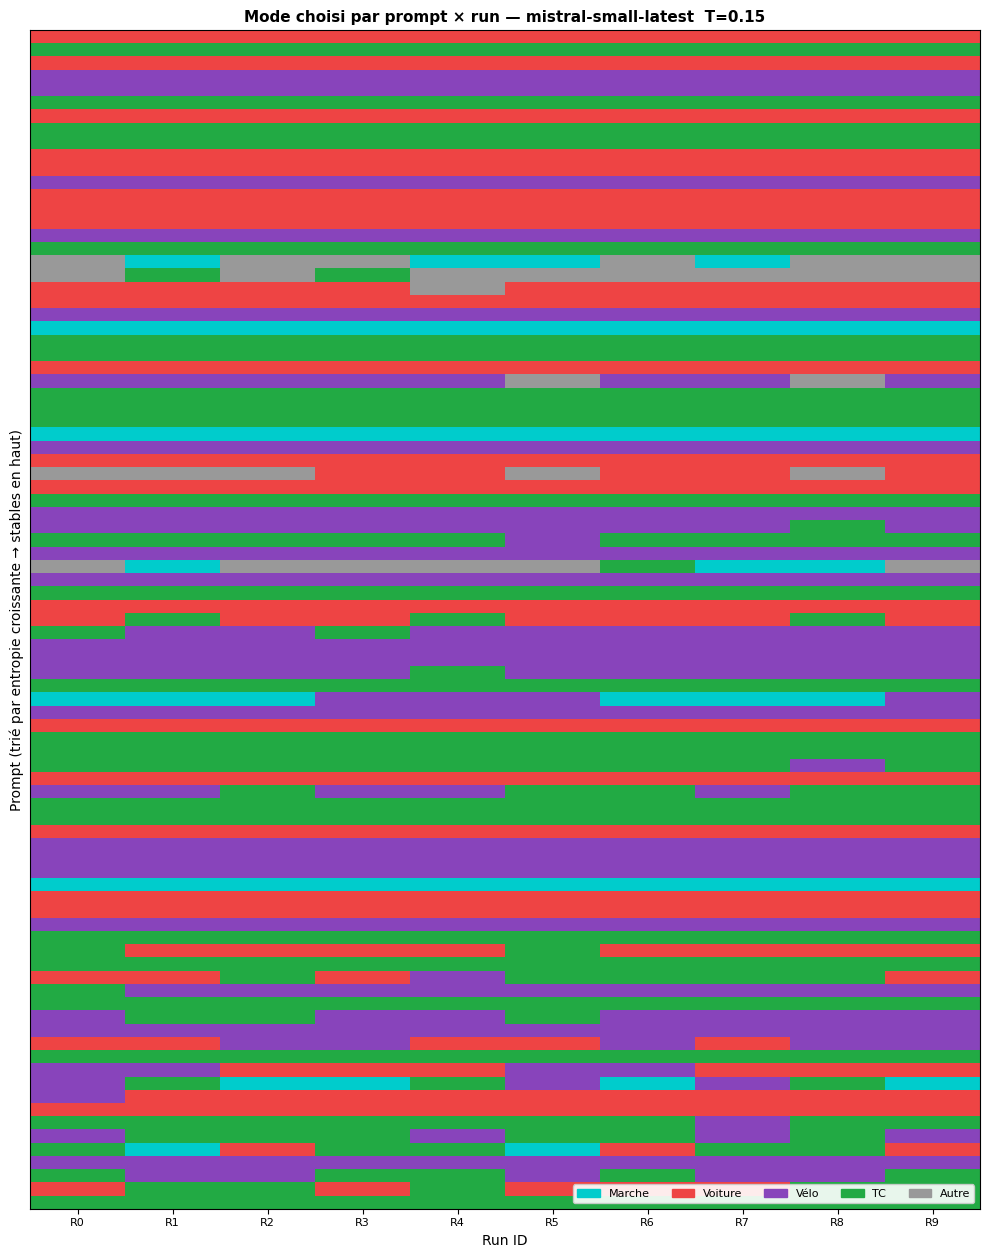

(Chaque ligne = 1 prompt, chaque colonne = 1 run. Les lignes en haut sont les plus stables.)


In [25]:
# ── Heatmap : prompt × run (mode choisi) ─────────────────────────────────────
# On prend le mode majoritaire parmi les agents de chaque (prompt_idx, run_id)
pivot_mode = (
    df_valid
    .groupby(['prompt_idx', 'run_id'])['mode_cat']
    .agg(lambda s: s.value_counts().index[0])
    .unstack(level='run_id')
)

MODE_TO_INT = {'Marche': 0, 'Vélo': 1, 'TC': 2, 'Voiture': 3, 'Autre': 4}
pivot_num   = pivot_mode.map(lambda m: MODE_TO_INT.get(m, 4))

# Trier par entropie croissante (les plus stables en haut)
sorted_idx  = per_prompt.sort_values('entropy')['prompt_idx'].values
pivot_sorted = pivot_num.reindex(sorted_idx)

cmap   = mcolors.ListedColormap([MODE_COLORS[m] for m in MODE_ORDER])
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]
norm   = mcolors.BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(min(n_runs * 0.8 + 2, 14), min(n_prompts * 0.12 + 2, 18)))
im = ax.imshow(pivot_sorted.values, aspect='auto', cmap=cmap, norm=norm,
               interpolation='nearest')

ax.set_xlabel('Run ID')
ax.set_ylabel('Prompt (trié par entropie croissante → stables en haut)')
ax.set_xticks(range(pivot_sorted.shape[1]))
ax.set_xticklabels([f'R{i}' for i in range(pivot_sorted.shape[1])], fontsize=8)
ax.set_yticks([])
ax.set_title(
    f'Mode choisi par prompt × run — {model_slug}  T={TEMPERATURE}',
    fontsize=11, fontweight='bold'
)

from matplotlib.patches import Patch
legend_patches = [Patch(color=MODE_COLORS[m], label=m) for m in MODE_ORDER]
ax.legend(handles=legend_patches, loc='lower right', fontsize=8,
          framealpha=0.9, ncol=len(MODE_ORDER))

plt.tight_layout()
plt.savefig(RESULTS_DIR / f'variability_heatmap_{model_slug}_T{TEMPERATURE}.png', dpi=150)
plt.show()
print('(Chaque ligne = 1 prompt, chaque colonne = 1 run. Les lignes en haut sont les plus stables.)')

/var/folders/sd/yfpxc_y13hqfry2rspfkspq80000gr/T/ipykernel_99573/1134968059.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(mode_groups, labels=mode_labels, patch_artist=True, notch=False)


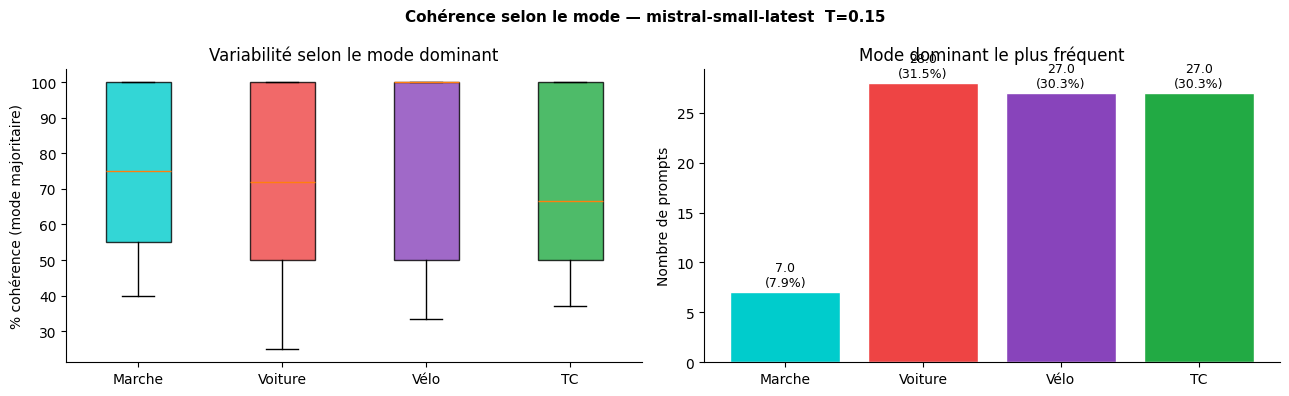

In [26]:
# ── Cohérence par mode majoritaire ────────────────────────────────────────────
# Pour les prompts dont le mode majoritaire est X, quelle est leur cohérence moyenne ?
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Cohérence selon le mode — {model_slug}  T={TEMPERATURE}', fontsize=11, fontweight='bold')

# Boxplot cohérence par mode majoritaire
ax = axes[0]
mode_groups = [per_prompt[per_prompt['majority_mode'] == m]['majority_pct'].values
               for m in MODE_ORDER if m in per_prompt['majority_mode'].values]
mode_labels  = [m for m in MODE_ORDER if m in per_prompt['majority_mode'].values]
bp = ax.boxplot(mode_groups, labels=mode_labels, patch_artist=True, notch=False)
for patch, label in zip(bp['boxes'], mode_labels):
    patch.set_facecolor(MODE_COLORS[label])
    patch.set_alpha(0.8)
ax.set_ylabel('% cohérence (mode majoritaire)')
ax.set_title('Variabilité selon le mode dominant')
ax.spines[['top', 'right']].set_visible(False)

# Fréquence des modes majoritaires
ax = axes[1]
mode_freq = per_prompt['majority_mode'].value_counts().reindex(MODE_ORDER).dropna()
bars = ax.bar(mode_freq.index, mode_freq.values,
              color=[MODE_COLORS[m] for m in mode_freq.index], edgecolor='white')
ax.set_ylabel('Nombre de prompts')
ax.set_title('Mode dominant le plus fréquent')
ax.spines[['top', 'right']].set_visible(False)
for bar, v in zip(bars, mode_freq.values):
    pct = v / len(per_prompt) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{v}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / f'variability_per_mode_{model_slug}_T{TEMPERATURE}.png', dpi=150)
plt.show()

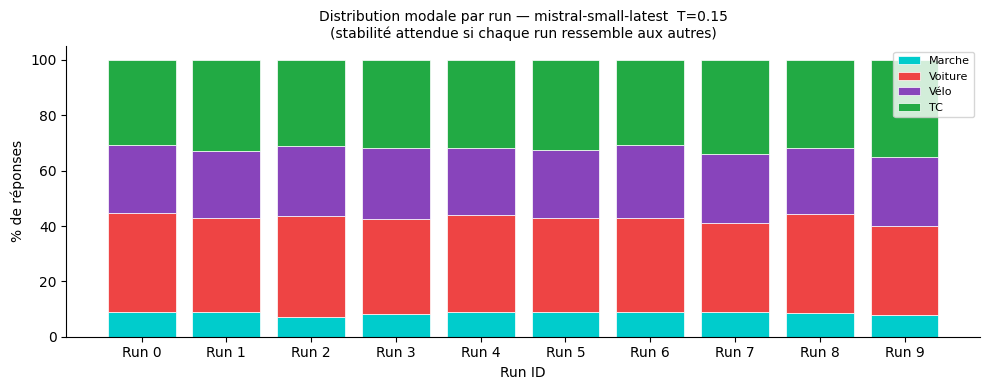

Écart-type de la distribution par run :
mode_cat
Marche     0.57
Voiture    1.53
Vélo       0.78
TC         1.37


In [27]:
# ── Stabilité run par run : le mode global change-t-il entre les runs ? ────────
run_dist = (
    df_valid
    .groupby('run_id')['mode_cat']
    .value_counts(normalize=True)
    .mul(100)
    .unstack(fill_value=0)
    .reindex(columns=[m for m in MODE_ORDER if m in df_valid['mode_cat'].unique()], fill_value=0)
)

fig, ax = plt.subplots(figsize=(10, 4))
bottom = np.zeros(len(run_dist))
for mode in run_dist.columns:
    ax.bar(run_dist.index, run_dist[mode], bottom=bottom,
           label=mode, color=MODE_COLORS.get(mode, '#999'), edgecolor='white', linewidth=0.5)
    bottom += run_dist[mode].values

ax.set_xlabel('Run ID')
ax.set_ylabel('% de réponses')
ax.set_title(
    f'Distribution modale par run — {model_slug}  T={TEMPERATURE}\n'
    f'(stabilité attendue si chaque run ressemble aux autres)',
    fontsize=10
)
ax.set_xticks(run_dist.index)
ax.set_xticklabels([f'Run {i}' for i in run_dist.index])
ax.legend(loc='upper right', fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(RESULTS_DIR / f'variability_runs_dist_{model_slug}_T{TEMPERATURE}.png', dpi=150)
plt.show()

print('Écart-type de la distribution par run :')
print(run_dist.std().round(2).to_string())

## 7 — Distribution globale LLM vs référence EMC² 2023

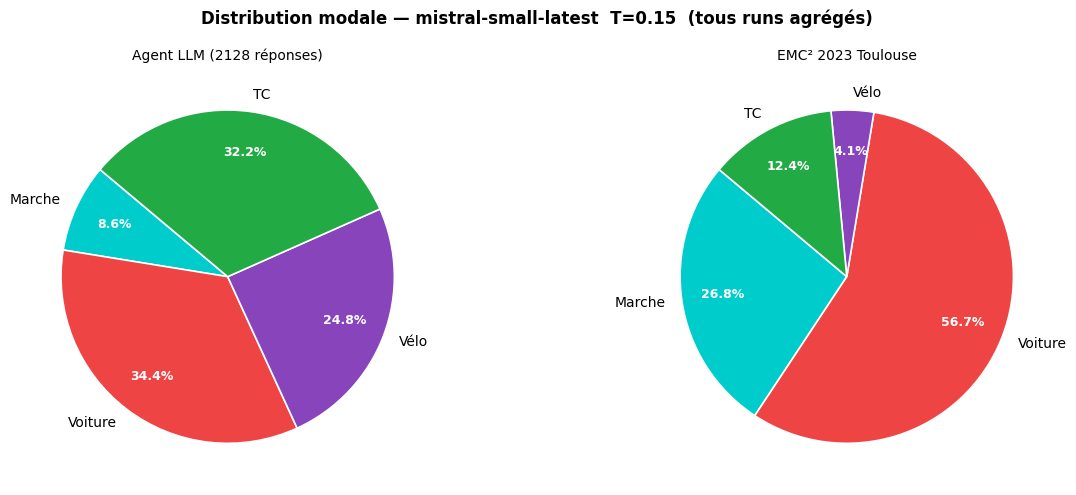

,LLM (%),EMC² (%),Écart (pp)
Marche,8.6,26.8,-18.3
Voiture,34.4,56.7,-22.3
Vélo,24.8,4.1,20.7
TC,32.2,12.4,19.9


In [28]:
# ── Distribution LLM agrégée (tous runs confondus) ───────────────────────────
llm_counts = df_valid['mode_cat'].value_counts()
llm_pct    = (llm_counts / len(df_valid) * 100).reindex(list(CEREMA_GLOBAL.keys())).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    f'Distribution modale — {model_slug}  T={TEMPERATURE}  (tous runs agrégés)',
    fontsize=12, fontweight='bold'
)

for ax, label, data in [
    (axes[0], f'Agent LLM ({len(df_valid)} réponses)', llm_pct),
    (axes[1], 'EMC² 2023 Toulouse', pd.Series(CEREMA_GLOBAL)),
]:
    total = data.sum()
    pct   = (data / total * 100) if total > 0 else data
    colors = [MODE_COLORS.get(m, '#999') for m in pct.index]
    wedge_props = {'edgecolor': 'white', 'linewidth': 1.2}
    wedges, texts, autotexts = ax.pie(
        pct.values, labels=pct.index, colors=colors,
        autopct='%1.1f%%', startangle=140,
        wedgeprops=wedge_props, pctdistance=0.75,
    )
    for at in autotexts:
        at.set_fontsize(9)
        at.set_color('white')
        at.set_fontweight('bold')
    ax.set_title(label, fontsize=10)

plt.tight_layout()
plt.savefig(RESULTS_DIR / f'variability_vs_cerema_{model_slug}_T{TEMPERATURE}.png', dpi=150)
plt.show()

# ── Tableau écarts LLM - EMC² ────────────────────────────────────────────────
cerema_s = pd.Series(CEREMA_GLOBAL, name='EMC² (%)')
cerema_s = cerema_s / cerema_s.sum() * 100
llm_s    = llm_pct.rename('LLM (%)').reindex(cerema_s.index).fillna(0)
gap_s    = (llm_s - cerema_s).rename('Écart (pp)')
pd.concat([llm_s.round(1), cerema_s.round(1), gap_s.round(1)], axis=1)

## 8 — Répartition des itinéraires choisis (index 1–5)

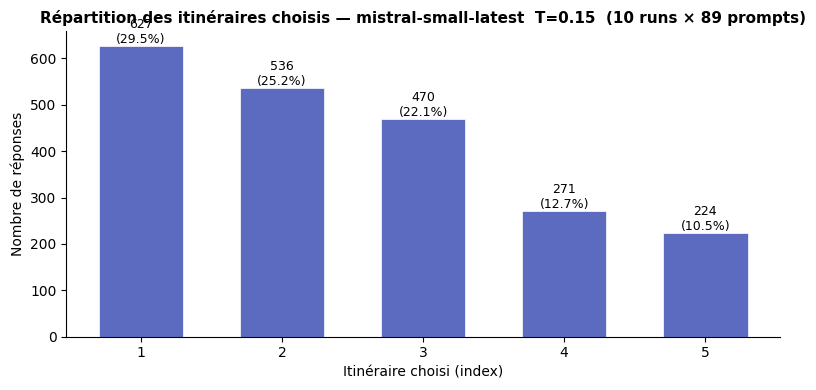

In [29]:
index_counts = df_valid['chosen_index'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    index_counts.index.astype(int),
    index_counts.values,
    color='#5C6BC0', edgecolor='white', linewidth=0.5, width=0.6
)
ax.set_xlabel('Itinéraire choisi (index)')
ax.set_ylabel('Nombre de réponses')
ax.set_title(
    f'Répartition des itinéraires choisis — {model_slug}  T={TEMPERATURE}  ({N_RUNS} runs × {n_prompts} prompts)',
    fontsize=11, fontweight='bold'
)
ax.set_xticks(range(1, 6))
ax.spines[['top', 'right']].set_visible(False)
for bar, v in zip(bars, index_counts.values):
    pct = v / len(df_valid) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{v}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / f'variability_index_{model_slug}_T{TEMPERATURE}.png', dpi=150)
plt.show()

## 9 — Tableau détaillé par mode

In [30]:
detail = (
    df_valid.groupby('mode_cat')
    .agg(
        n_responses=('mode_cat', 'count'),
        n_agents=('agent_id', 'nunique'),
        avg_chosen_index=('chosen_index', 'mean'),
        avg_reason_len=('reason', lambda s: s.str.len().mean()),
    )
    .assign(pct=lambda d: (d['n_responses'] / d['n_responses'].sum() * 100).round(1))
    [['n_responses', 'pct', 'n_agents', 'avg_chosen_index', 'avg_reason_len']]
    .sort_values('n_responses', ascending=False)
)
detail.columns = ['Réponses', '% total', 'Agents uniques', 'Index moyen', 'Long. raison moy.']
detail.index.name = 'Mode'
detail

,Réponses,% total,Agents uniques,Index moyen,Long. raison moy.
Mode,,,,,
Voiture,732,34.4,55,2.461749,270.637978
TC,686,32.2,54,2.252187,253.695335
Vélo,528,24.8,31,2.859848,280.340909
Marche,182,8.6,16,2.505495,253.170330


## 10 — Synthèse globale

In [31]:
summary = pd.DataFrame({
    'Modèle':              model_slug,
    'Température':         TEMPERATURE,
    'N runs':              n_runs,
    'N prompts':           n_prompts,
    'Cohérence moy. (%)':  per_prompt['majority_pct'].mean().round(1),
    'Cohérence min (%)':   per_prompt['majority_pct'].min().round(1),
    'Entropie moy. (bits)': per_prompt['entropy'].mean().round(3),
    'Entropie norm. moy.': per_prompt['entropy_norm'].mean().round(3),
    'Modes distincts moy.': per_prompt['n_distinct_modes'].mean().round(2),
    'Prompts 100% stables': (per_prompt['majority_pct'] == 100).sum(),
    'Prompts ≥ 3 modes':   (per_prompt['n_distinct_modes'] >= 3).sum(),
}, index=[0])

summary_path = RESULTS_DIR / f'variability_summary_{model_slug}_T{TEMPERATURE}.csv'
summary.to_csv(summary_path, index=False)
print(f'Résumé sauvegardé → {summary_path}')
summary.T

Résumé sauvegardé → results/variability_summary_mistral-small-latest_T0.15.csv


,0
Modèle,mistral-small-latest
Température,0.15
N runs,10
N prompts,89
Cohérence moy. (%),73.5
Cohérence min (%),25.0
Entropie moy. (bits),0.7
Entropie norm. moy.,0.35
Modes distincts moy.,1.96
Prompts 100% stables,37


## 11 — Variabilité « pure » run-à-run (même prompt, même agent)

Les sections précédentes mélangeaient deux sources de variabilité :
- la **diversité légitime entre agents** d'un même ménage (la grand-mère prend le bus, le jeune le vélo) ;
- l'**instabilité du modèle** quand on relance le *même* prompt.

Pour isoler l'instabilité réelle, on regroupe par `(prompt_idx, agent_id)` et on mesure,
sur les `N_RUNS` répétitions, à quel point **le même agent** répond la même chose.

- **Cohérence agent** : % des runs où l'agent choisit son mode majoritaire (100 % = parfaitement déterministe).
- **Taux d'accord par paire** : probabilité que deux runs tirés au hasard donnent le même mode.
- On agrège ensuite au niveau du prompt (moyenne de ses agents), puis globalement.

In [32]:
def pairwise_agreement(series: pd.Series) -> float:
    """Proba que 2 runs tirés au hasard donnent le même mode (= somme des p_i²)."""
    p = series.value_counts(normalize=True).values
    return float((p ** 2).sum())


# ── Cohérence au niveau (prompt, agent) : la vraie répétabilité du modèle ──────
per_agent = (
    df_valid
    .groupby(['prompt_idx', 'agent_id'])['mode_cat']
    .agg(
        n_runs_seen='count',
        agent_consistency=majority_pct,        # % runs → mode majoritaire de l'agent
        pair_agreement=pairwise_agreement,     # accord par paire de runs
        n_distinct_modes=lambda s: s.nunique(),
    )
    .reset_index()
)

# On ne garde que les agents observés sur ≥ 2 runs (sinon la cohérence est triviale)
multi = per_agent[per_agent['n_runs_seen'] >= 2]

# Agrégation par prompt (moyenne de ses agents) puis globale
per_prompt_pure = (
    multi.groupby('prompt_idx')
    .agg(
        mean_agent_consistency=('agent_consistency', 'mean'),
        mean_pair_agreement=('pair_agreement', 'mean'),
        n_agents=('agent_id', 'nunique'),
    )
    .reset_index()
)

print('Variabilité run-à-run isolée (même prompt + même agent) :')
print(f"  Agents évalués (≥2 runs)                : {len(multi)}")
print(f"  Cohérence agent moyenne                 : {multi['agent_consistency'].mean():.1f}%")
print(f"  Accord par paire moyen                  : {multi['pair_agreement'].mean()*100:.1f}%")
print(f"  Agents 100% déterministes               : {(multi['agent_consistency'] == 100).mean()*100:.1f}%")
print(f"  Agents avec ≥2 modes sur les runs       : {(multi['n_distinct_modes'] >= 2).mean()*100:.1f}%")
print()
print('Même chose moyennée d\'abord par prompt (chaque prompt compte pareil) :')
print(f"  Cohérence agent moy. par prompt         : {per_prompt_pure['mean_agent_consistency'].mean():.1f}%")
print(f"  Accord par paire moy. par prompt        : {per_prompt_pure['mean_pair_agreement'].mean()*100:.1f}%")
print()
print('Rappel — cohérence « brute » (agents + runs mélangés) : '
      f"{per_prompt['majority_pct'].mean():.1f}%")

Variabilité run-à-run isolée (même prompt + même agent) :
  Agents évalués (≥2 runs)                : 225
  Cohérence agent moyenne                 : 93.7%
  Accord par paire moyen                  : 91.7%
  Agents 100% déterministes               : 76.4%
  Agents avec ≥2 modes sur les runs       : 23.6%

Même chose moyennée d'abord par prompt (chaque prompt compte pareil) :
  Cohérence agent moy. par prompt         : 94.4%
  Accord par paire moy. par prompt        : 92.6%

Rappel — cohérence « brute » (agents + runs mélangés) : 73.5%
